# Phase 1 — Exploratory Data Analysis

Covers T1.4: class balance (banking77), text length distribution (both corpora), sample tickets.
Run `python -m src.data.ingest_banking77` and `python -m src.data.ingest_twitter_support` first.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

banking = pd.read_csv("../data/processed/banking77_train.csv")
twitter = pd.read_csv("../data/processed/twitter_support.csv")
banking.shape, twitter.shape

((9999, 3), (8000, 2))

## banking77 class balance

77 intents. Not necessarily balanced — confirming this matters because a skewed class would
change how we read precision/recall in Phase 2.

min class size: 35, max class size: 187, mean: 129.9


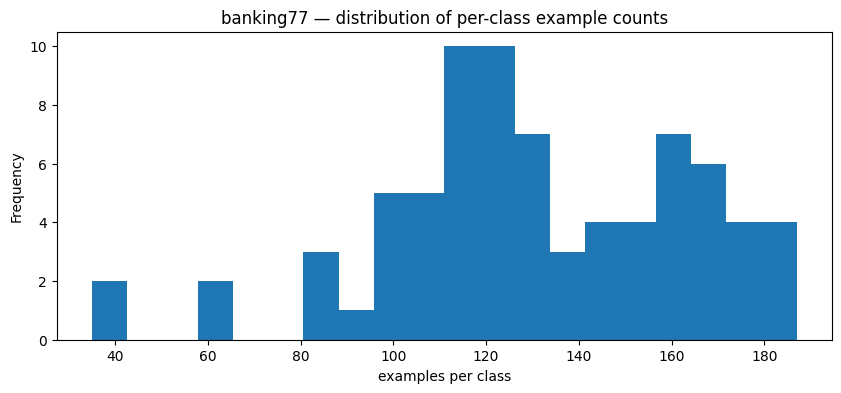

In [2]:
counts = banking["label_name"].value_counts()
print(f"min class size: {counts.min()}, max class size: {counts.max()}, mean: {counts.mean():.1f}")
fig, ax = plt.subplots(figsize=(10, 4))
counts.plot(kind="hist", bins=20, ax=ax)
ax.set_title("banking77 — distribution of per-class example counts")
ax.set_xlabel("examples per class")
plt.show()

## Text length distribution

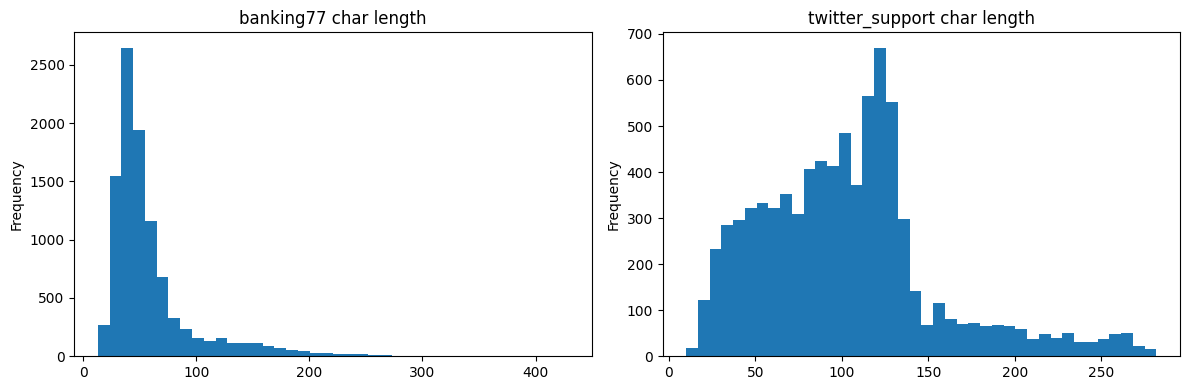

banking77:
 count    9999.000000
mean       59.414741
std        40.778066
min        13.000000
25%        36.000000
50%        47.000000
75%        64.000000
max       429.000000
Name: ticket_text, dtype: float64

twitter_support:
 count    8000.000000
mean      103.052625
std        51.407375
min        10.000000
25%        66.000000
50%       101.000000
75%       126.000000
max       282.000000
Name: ticket_text, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
banking["ticket_text"].str.len().plot(kind="hist", bins=40, ax=axes[0], title="banking77 char length")
twitter["ticket_text"].str.len().plot(kind="hist", bins=40, ax=axes[1], title="twitter_support char length")
plt.tight_layout()
plt.show()
print("banking77:\n", banking["ticket_text"].str.len().describe())
print("\ntwitter_support:\n", twitter["ticket_text"].str.len().describe())

## Sample tickets

Spot-check that cleaning (PII stripping, whitespace normalization) didn't mangle content.

In [4]:
print("-- banking77 samples --")
for _, row in banking.sample(5, random_state=1).iterrows():
    print(f"[{row['label_name']}] {row['ticket_text']}")

print("\n-- twitter_support samples --")
for _, row in twitter.sample(5, random_state=1).iterrows():
    print(f"[{row['ticket_id']}] {row['ticket_text']}")

-- banking77 samples --
[pending_top_up] What is the reason that my top-up is still pending?
[lost_or_stolen_phone] Do I need to do anything? My phone was stolen yesterday.
[fiat_currency_support] Do you have a problem with EUR exchanges?
[pin_blocked] Would you please unblock my pin? I don't know why, but it's blocked.
[transfer_not_received_by_recipient] Why hasn't a transaction I did to my friend arrived yet?

-- twitter_support samples --
[TW-004740] its been one week!!
[TW-005606] huge disappointment trying to book travel. You just lost me as a customer for good
[TW-004824] So I’m supposed to just wait and see? You’ve already charged me for the tree. Do you know where the tree is? I don’t, and the USPS shows they haven’t received it.
[TW-004205] why is my service messed up again?
[TW-003228] Acabei de mandar um email


## Findings

- banking77 is moderately imbalanced across its 77 intents: per-class train counts range from
  35 to 187 examples (mean ~130). Not extreme, but real enough that Phase 2 should look at
  per-class recall for the smallest classes specifically, not just macro-averaged metrics.
- banking77 tickets are short, single-intent queries (median ~47 chars); twitter_support tickets
  are longer and noisier (median ~101 chars, informal language, occasional profanity/sarcasm,
  some non-English text — e.g. TW-003228 above is Portuguese) — expected, since it's real
  social-media text rather than a curated intent-classification set. This makes twitter_support
  a reasonable stand-in for "unlabeled real-world tickets" for clustering/retrieval
  (Phases 3-4), distinct in character from the labeled classifier corpus.
- No PII-shaped tokens (emails/phones/URLs/@handles) survived cleaning in the sampled rows
  checked above.
- Caveat for later phases: the twitter_support sample isn't purely English (see TW-003228). If
  clustering/retrieval quality suffers from mixed-language noise in Phase 3/4, filtering to
  English-detected rows is the fix — noted here rather than pre-emptively "solved" now.